<a href="https://colab.research.google.com/github/faisu6339-glitch/Machine-learning/blob/main/Boosting(Adaboost).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Boosting in Supervised Machine Learning

**Boosting** is an ensemble learning technique that aims to improve the prediction accuracy of a weak learner (typically a decision tree, often referred to as a "stump" if it's a very shallow tree) by sequentially building a series of models. The core idea is to train subsequent models to focus on the mistakes made by previous models, thereby progressively reducing bias and variance.

### How Boosting Works:

1.  **Initial Model:** A base model (weak learner) is trained on the original dataset.
2.  **Weighted Data:** After the first model makes predictions, the data points that were misclassified or had higher errors are given increased weights (or their importance is emphasized).
3.  **Sequential Training:** A new base model is trained on this re-weighted dataset, paying more attention to the previously misclassified examples.
4.  **Iteration:** Steps 2 and 3 are repeated for a specified number of iterations. Each new model tries to correct the errors of the previous ones.
5.  **Final Prediction:** The predictions from all the individual base models are combined, usually through a weighted average (for regression) or a weighted majority vote (for classification), to produce the final, strong prediction.

### Key Concepts:

*   **Weak Learners:** Simple models that perform slightly better than random guessing. Decision trees, especially shallow ones, are commonly used.
*   **Sequential Learning:** Models are built one after another, with each new model learning from the errors of its predecessors.
*   **Adaptive Weighting:** The process of adjusting data point weights (or focusing on residuals) to highlight challenging examples.
*   **Bias-Variance Trade-off:** Boosting primarily aims to reduce bias (underfitting) by iteratively improving the model's ability to fit the training data. While it can reduce variance, it's generally more focused on bias reduction compared to bagging methods like Random Forests.

### Popular Boosting Algorithms:

1.  **AdaBoost (Adaptive Boosting):**
    *   One of the earliest and most influential boosting algorithms.
    *   It re-weights training instances at each iteration, giving higher weights to misclassified examples.
    *   The final prediction is a weighted sum of the weak learners' predictions, where learners that perform better are given higher weights.

2.  **Gradient Boosting (e.g., Gradient Boosting Machines - GBM):**
    *   Instead of re-weighting data points, GBMs train subsequent models on the **residuals** (the errors) of the previous models.
    *   Each new tree tries to predict the residual errors made by the ensemble so far.
    *   It uses gradient descent to minimize the loss function.

3.  **XGBoost (eXtreme Gradient Boosting):**
    *   An optimized and highly efficient implementation of gradient boosting.
    *   Includes regularization (L1 and L2) to prevent overfitting.
    *   Supports parallel processing and handles missing values internally.
    *   Widely popular in Kaggle competitions due to its speed and performance.

4.  **LightGBM (Light Gradient Boosting Machine):**
    *   Another high-performance gradient boosting framework.
    *   Uses a leaf-wise (rather than level-wise) tree growth algorithm, which can lead to faster training and better accuracy for certain datasets.
    *   Optimized for large datasets.

5.  **CatBoost (Categorical Boosting):**
    *   A gradient boosting library that excels at handling categorical features automatically.
    *   Uses a novel algorithm to prevent prediction shift and provides robust out-of-the-box performance.

### Advantages of Boosting:

*   **High Accuracy:** Often achieves state-of-the-art performance on a wide range of supervised learning tasks.
*   **Reduces Bias:** By iteratively correcting errors, boosting models are very good at capturing complex relationships in the data.
*   **Versatility:** Can be used for both classification and regression problems.

### Disadvantages of Boosting:

*   **Prone to Overfitting:** Since models are built sequentially and focus on errors, boosting can be sensitive to noisy data and outliers, potentially leading to overfitting if not carefully tuned.
*   **Computationally Intensive:** Sequential nature makes it harder to parallelize compared to bagging methods.
*   **Requires Tuning:** Many hyperparameters need to be tuned for optimal performance.

### When to Use Boosting:

Boosting is a powerful technique for tasks where high predictive accuracy is crucial and you have sufficient computational resources. It's particularly effective when dealing with complex datasets and can often outperform other algorithms if well-tuned.

## AdaBoost (Adaptive Boosting)

**AdaBoost** (short for Adaptive Boosting) is one of the earliest and most popular boosting algorithms, introduced by Yoav Freund and Robert Schapire in 1995. It's primarily used for classification tasks, though adaptations for regression exist. The core idea behind AdaBoost is to combine many "weak learners" (models that perform slightly better than random chance) to create a single "strong learner" that can make accurate predictions.

### How AdaBoost Works (for Binary Classification):

1.  **Initialize Weights:**
    *   Initially, all training data points are assigned equal weights. If there are `N` data points, each gets a weight of `1/N`. These weights are used to emphasize certain data points during the training of subsequent weak learners.

2.  **Iterative Training of Weak Learners:**
    *   For a specified number of iterations (or until a desired accuracy is reached), AdaBoost sequentially trains a series of weak learners (typically decision stumps, which are one-level decision trees).

    *   **Train a Weak Learner:** A weak learner `h_t(x)` is trained on the training data, taking into account the current weights of the data points. The goal of this weak learner is to minimize the weighted error.

    *   **Calculate Error Rate:** The error rate (`epsilon_t`) of the weak learner `h_t(x)` is calculated as the sum of weights of the misclassified training examples.
        `epsilon_t = sum(w_i * I(y_i != h_t(x_i))) / sum(w_i)` where `I` is the indicator function.

    *   **Calculate Learner Weight (`alpha_t`):** A weight (`alpha_t`) is assigned to the weak learner `h_t(x)` based on its accuracy. More accurate learners get higher weights.
        `alpha_t = 0.5 * log((1 - epsilon_t) / epsilon_t)`. This ensures that if a learner performs well (low `epsilon_t`), its `alpha_t` is large and positive, and if it performs poorly (high `epsilon_t` close to 0.5), its `alpha_t` is small or negative.

    *   **Update Data Weights:** The weights of the training data points are updated for the next iteration:
        *   **Misclassified points:** The weights of misclassified data points are increased. This forces the next weak learner to focus more on these difficult examples.
        *   **Correctly classified points:** The weights of correctly classified data points are decreased.
        *   The new weights are then normalized so that they sum up to 1.
        `w_{i,t+1} = w_{i,t} * exp(-alpha_t * y_i * h_t(x_i))`
        Then, normalize: `w_{i,t+1} = w_{i,t+1} / sum(w_{j,t+1})`

3.  **Combine Weak Learners:**
    *   After all iterations, the final strong learner `H(x)` is a weighted sum of all the individual weak learners:
        `H(x) = sign(sum(alpha_t * h_t(x)))`
    *   The `sign` function is used for binary classification to assign the final class label.

### Key Characteristics of AdaBoost:

*   **Focuses on Hard Examples:** By increasing the weights of misclassified data points, AdaBoost adaptively focuses on the examples that are difficult to classify, forcing subsequent models to learn from these mistakes.
*   **Sequential Learning:** It's a sequential process where each weak learner is influenced by the performance of the previous ones.
*   **Adaptive Combination:** Weak learners are combined with weights proportional to their accuracy, giving more influence to better-performing models.
*   **Weak Learners are Simple:** Typically uses very simple models (e.g., decision stumps) to keep individual models weak and ensure that the ensemble benefits from diversity.

### Advantages of AdaBoost:

*   **Simple to Implement:** The core algorithm is relatively straightforward.
*   **Robust:** Less prone to overfitting compared to some other boosting algorithms if the number of weak learners is not excessively large.
*   **No Hyperparameter Tuning for Weak Learners:** Often uses decision stumps, which don't require much tuning.
*   **Effective:** Can achieve very high accuracy and is considered a strong baseline for many classification tasks.

### Disadvantages of AdaBoost:

*   **Sensitive to Noisy Data/Outliers:** Because it focuses heavily on misclassified examples, noisy data or outliers can be given extremely high weights, leading to the model trying to fit the noise and potentially overfitting.
*   **Computationally Intensive:** Sequential training means it can be slower than parallelizable algorithms.

### Applications:

AdaBoost has been successfully applied in various fields, including:
*   **Face Detection:** The Viola-Jones object detection framework, famous for real-time face detection, uses AdaBoost with Haar-like features.
*   **Image Recognition:** For classifying objects in images.
*   **Bioinformatics:** For classifying biological data.

AdaBoost laid the foundation for many subsequent, more advanced boosting algorithms like Gradient Boosting Machines (GBM), XGBoost, LightGBM, and CatBoost.

## Python Example: AdaBoost with Scikit-learn

This example demonstrates how to use `AdaBoostClassifier` from scikit-learn for a binary classification task. We'll use a synthetic dataset for illustration.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. Generate a synthetic dataset
X, y = make_classification(n_samples=300, n_features=2, n_informative=2,
                           n_redundant=0, n_repeated=0, n_classes=2,
                           n_clusters_per_class=1, random_state=42)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, {y_test.shape}")

Training data shape: (210, 2), (210,)
Testing data shape: (90, 2), (90,)


Let's visualize the synthetic dataset to understand its structure.

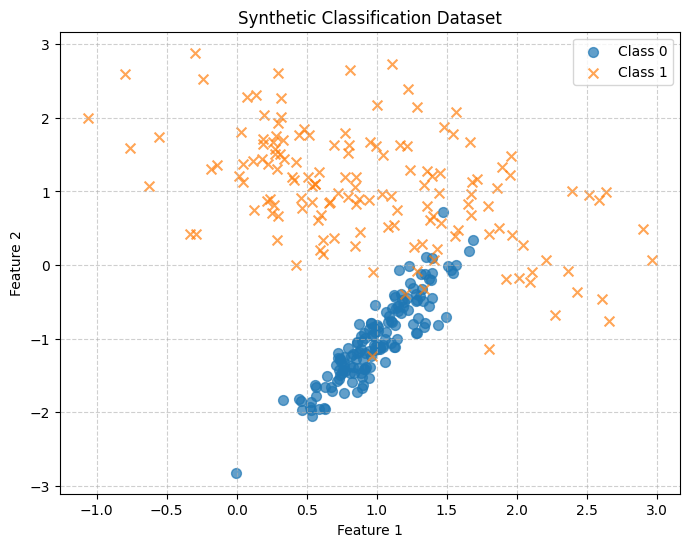

In [ ]:
# Plot the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label='Class 0', marker='o', s=50, alpha=0.7)
plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Class 1', marker='x', s=50, alpha=0.7)
plt.title('Synthetic Classification Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Now, let's train the AdaBoost Classifier. We'll use a `DecisionTreeClassifier` with `max_depth=1` (a decision stump) as the base estimator, which is a common choice for AdaBoost.

In [ ]:
# 2. Initialize and train the AdaBoostClassifier
# We use a DecisionTreeClassifier with max_depth=1 (decision stump) as the base estimator
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

adaboost_model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=50,  # Number of weak learners (stumps) to train
    learning_rate=1.0, # Contribution of each weak learner
    random_state=42
)

adaboost_model.fit(X_train, y_train)

print("AdaBoost model training complete.")

AdaBoost model training complete.


After training, we can evaluate the model's performance on the test set.

In [ ]:
# 3. Make predictions on the test set
y_pred = adaboost_model.predict(X_test)

# 4. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on the test set: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy on the test set: 0.9556

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        46
           1       0.98      0.93      0.95        44

    accuracy                           0.96        90
   macro avg       0.96      0.96      0.96        90
weighted avg       0.96      0.96      0.96        90



Finally, let's visualize the decision boundary learned by the AdaBoost model.

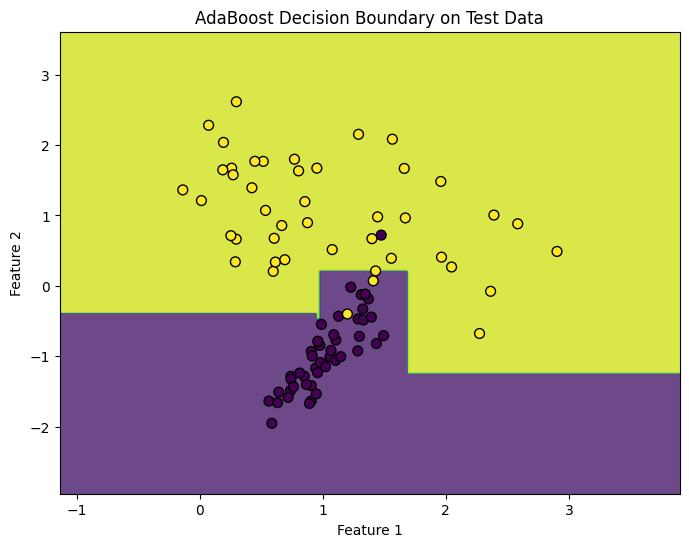

In [ ]:
# 5. Visualize the decision boundary

def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                           np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolor='k')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

plot_decision_boundary(X_test, y_test, adaboost_model, 'AdaBoost Decision Boundary on Test Data')

# Classification Programs

# # AdaBoost Classifier - Iris Classification


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# 1. Load Dataset
iris = load_iris()

X = iris.data
y = iris.target

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (150, 4)
Target Shape: (150,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)


In [ ]:
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)



Accuracy: 0.9666666666666667


In [ ]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

#. Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)


Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

